# Preprocesamiento de Datos: Marco temporal Diario (1d)

Este notebook contiene el pipeline de ingeniería de datos para el marco temporal Macro (Daily). El objetivo es transformar los datos brutos de precios de cierre en un espacio de estados ($s_t$) optimizado para el entrenamiento de modelos de State Representation Learning (SRL) y agentes de Deep Reinforcement Learning (DRL).

## Librerías

Se utilizan librerías estándar para manipulación de datos (Pandas, NumPy), herramientas de interpolación matemática (SciPy) y la implementación personalizada de la Transformada Wavelet Discreta (MODWT) para el filtrado de ruido.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from scipy.interpolate import CubicSpline

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler

import sys
sys.path.append('../')

from src.modwt import *

import pywt
from pywt import wavedec
from pywt import Wavelet

Se definen los rangos temporales para asegurar la consistencia entre los marcos de 1h y 1d. El periodo de estudio abarca desde finales de 2021 hasta mediados de 2025, cubriendo diversos ciclos de mercado para mejorar la robustez del modelo.

In [2]:
ref_data_range = "1D"
from_date = '2021-12-31 00:00:00'
until_date = '2025-07-31 00:00:00'
until_date_2 = '2025-08-01 00:00:00'

In [3]:
# list_data_name = ["BTCUSDT_1d", "ETHUSDT_1d", "BNBUSDT_1d", "XRPUSDT_1d", "ADAUSDT_1d", "LTCUSDT_1d"]

list_data_name = ["BTCUSDT_1d"]

Para el criptoactivo (BTCUSDT) se ejecutan los siguientes pasos críticos:

1. Sincronización de Calendario: Reindexación para detectar huecos temporales y asegurar una serie continua.

2. Interpolación por Splines Cúbicos: Relleno de datos faltantes preservando la estructura geométrica de la señal, a diferencia de los métodos lineales simples.

3. Estacionariedad (Log-Returns): Conversión de precios nominales a retornos logarítmicos para estabilizar la media y varianza.

4. Normalización Adaptativa: Tratamiento de outliers mediante cuantiles (2%-98%) y escalado Min-Max al rango [-1, 1].

5. Análisis Multiresolución (MODWT): Descomposición de la señal mediante Wavelets para separar la tendencia estructural del ruido transaccional de alta frecuencia.

In [4]:
for data_name in list_data_name:
    # 1. Importación
    ccy = data_name.split('_')[0]
    data = pd.read_csv(f'../data/{data_name}_data_from_20210101_to_20251031.csv')
    
    print(f"--- Diagnóstico Macro (1d): {data_name} ---")
    print(f"Filas totales en el CSV original: {len(data)}")

    data['date'] = pd.to_datetime(data['date'], format='ISO8601').dt.normalize()
    data.set_index('date', inplace=True)
    data = data[~data.index.duplicated(keep='first')]
    data.sort_index(inplace=True)

    # 2. Recorte temporal
    start_ts = pd.to_datetime(from_date)
    end_ts = pd.to_datetime(until_date_2)
    data = data.loc[start_ts : end_ts]
    print(f"Filas tras filtrar fechas ({from_date} a {until_date_2}): {len(data)}")

    # 3. Sincronización de Calendario Diario
    my_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')
    data = data.reindex(my_range)
    print(f"Filas tras sincronizar calendario (rellenando huecos): {len(data)}")

    # 4. Interpolación de Valores Faltantes (Cubic Spline)
    data_interp_temp = data.copy()
    data_interp_temp.reset_index(inplace=True)
    data_interp_temp.rename(columns={'index': 'date'}, inplace=True)
    data_interp_temp['date_ordinal'] = data_interp_temp['date'].apply(lambda x: x.timestamp())

    known_data = data_interp_temp.dropna(subset=['close'])
    if len(known_data) > 1:
        cs = CubicSpline(known_data['date_ordinal'], known_data['close'])
        missing_idx = data_interp_temp[data_interp_temp['close'].isnull()].index
        if not missing_idx.empty:
            data_interp_temp.loc[missing_idx, 'close'] = cs(data_interp_temp.loc[missing_idx, 'date_ordinal'])
    
    data_interp_temp.set_index('date', inplace=True)
    data = data_interp_temp.copy()

    # 5. Log Returns 
    data['processed_log_return'] = np.log(data['close'] / data['close'].shift(1))
    data.dropna(subset=['processed_log_return'], inplace=True)
    print(f"Filas listas para normalizar: {len(data)}")

    # 6. Outliers y Normalización
    if len(data) > 0:
        lower_limit = data['processed_log_return'].quantile(0.02)
        upper_limit = data['processed_log_return'].quantile(0.98)
        clipped_series = data['processed_log_return'].clip(lower=lower_limit, upper=upper_limit)
        
        scaler = MinMaxScaler(feature_range=(-1, 1))
        data['normalized_outliers_processed_log_return'] = scaler.fit_transform(clipped_series.values.reshape(-1, 1))
        print(f"Normalización completada. Rango: [{data['normalized_outliers_processed_log_return'].min():.2f}, {data['normalized_outliers_processed_log_return'].max():.2f}]")
    else:
        continue

    # 7. MODWT (Denoising) y Sumas Multiresolución
    wt = modwt(data['normalized_outliers_processed_log_return'], 'db2', 5)
    wtmra = modwtmra(wt, 'db2')
    df_wtmra = pd.DataFrame(wtmra).transpose()
    df_wtmra.columns = [f'processed_log_return_wtmra_{i}' for i in range(6)]
    
    # SUMAS MANUALES
    # Perspectiva de bajas frecuencias (Trend-focused)
    df_wtmra['processed_log_return_wtmra_5_4'] = df_wtmra['processed_log_return_wtmra_5'] + df_wtmra['processed_log_return_wtmra_4']
    df_wtmra['processed_log_return_wtmra_5_4_3'] = df_wtmra['processed_log_return_wtmra_5_4'] + df_wtmra['processed_log_return_wtmra_3']
    df_wtmra['processed_log_return_wtmra_5_4_3_2'] = df_wtmra['processed_log_return_wtmra_5_4_3'] + df_wtmra['processed_log_return_wtmra_2']
    df_wtmra['processed_log_return_wtmra_5_4_3_2_1'] = df_wtmra['processed_log_return_wtmra_5_4_3_2'] + df_wtmra['processed_log_return_wtmra_1']
    df_wtmra['processed_log_return_wtmra_5_4_3_2_1_0'] = df_wtmra['processed_log_return_wtmra_5_4_3_2_1'] + df_wtmra['processed_log_return_wtmra_0']

    # Perspectiva de altas frecuencias (Noise-focused)
    df_wtmra['processed_log_return_wtmra_0_1'] = df_wtmra['processed_log_return_wtmra_0'] + df_wtmra['processed_log_return_wtmra_1']
    df_wtmra['processed_log_return_wtmra_0_1_2'] = df_wtmra['processed_log_return_wtmra_0_1'] + df_wtmra['processed_log_return_wtmra_2']
    df_wtmra['processed_log_return_wtmra_0_1_2_3'] = df_wtmra['processed_log_return_wtmra_0_1_2'] + df_wtmra['processed_log_return_wtmra_3']
    df_wtmra['processed_log_return_wtmra_0_1_2_3_4'] = df_wtmra['processed_log_return_wtmra_0_1_2_3'] + df_wtmra['processed_log_return_wtmra_4']
    df_wtmra['processed_log_return_wtmra_0_1_2_3_4_5'] = df_wtmra['processed_log_return_wtmra_0_1_2_3_4'] + df_wtmra['processed_log_return_wtmra_5']

    df_wtmra.index = data.index
    data = data.join(df_wtmra)

    # 8. Guardado y limpieza final
    data.dropna(inplace=True)
    print(f"¿Hay valores nulos finales?: {data.isnull().values.any()}")
    print(f"Total de filas guardadas en el CSV: {len(data)}")
    
    from_safe = from_date.replace(":", "-").replace(" ", "_")
    until_safe = until_date.replace(":", "-").replace(" ", "_")
    output_file = f'../data/01-output-{ccy}_1d-from-{from_safe}-until-{until_safe}-log-return.csv'
    data.to_csv(output_file, index=True)

--- Diagnóstico Macro (1d): BTCUSDT_1d ---
Filas totales en el CSV original: 3118
Filas tras filtrar fechas (2021-12-31 00:00:00 a 2025-08-01 00:00:00): 1310
Filas tras sincronizar calendario (rellenando huecos): 1310
Filas listas para normalizar: 1309
Normalización completada. Rango: [-1.00, 1.00]
¿Hay valores nulos finales?: False
Total de filas guardadas en el CSV: 1309


Una vez procesada la serie, se verifica que la señal sea estacionaria y que esté correctamente acotada en el rango de activación del modelo. Las siguientes gráficas contrastan el precio bruto frente a la representación final de entrada (Log-Return Normalizado con Denoising).

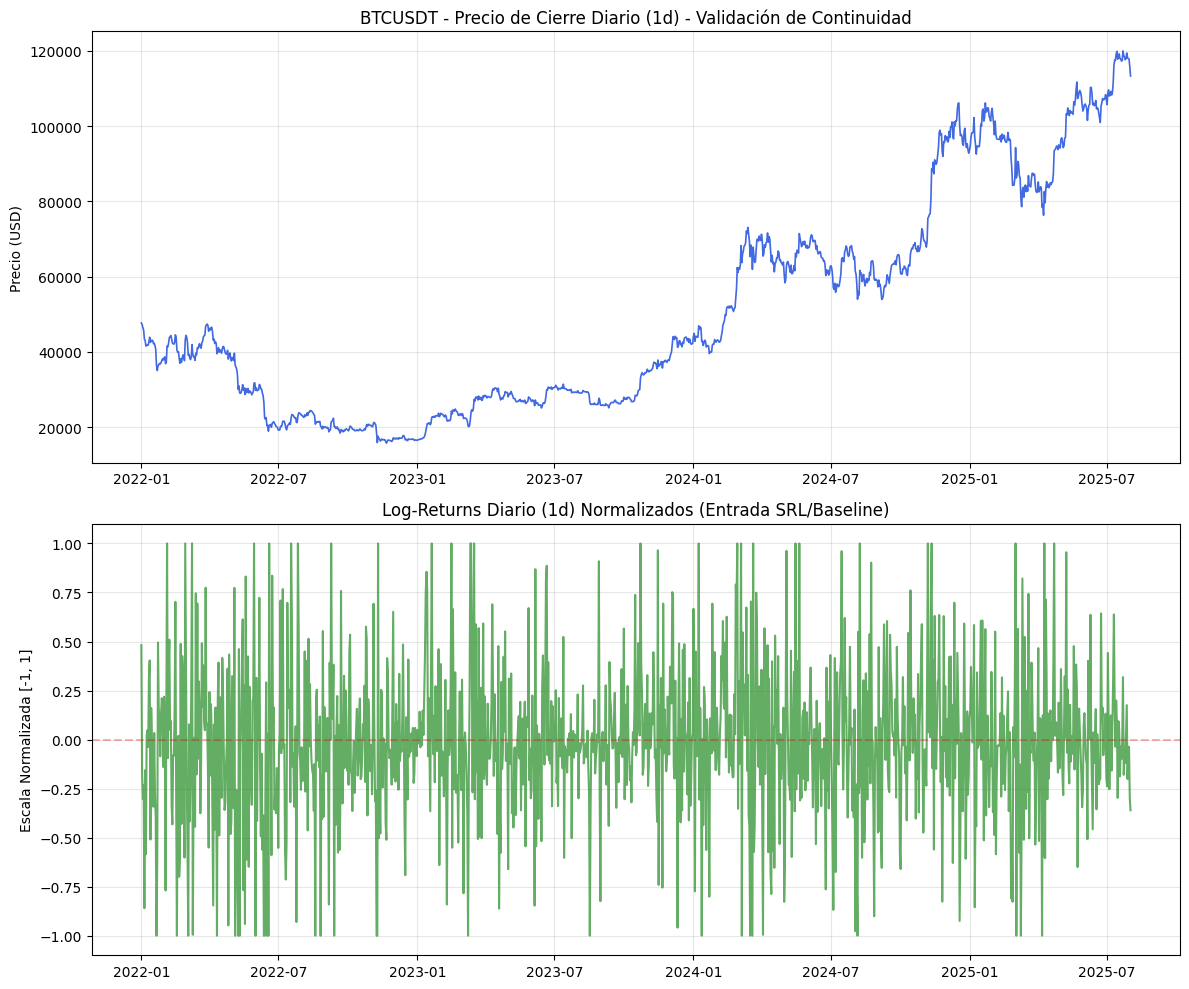

 DIAGNÓSTICO DE INTEGRIDAD: MARCO DIARIO (1D)
- Rango temporal:      2022-01-01 00:00:00 a 2025-08-01 00:00:00
- Total observaciones: 1309
- ¿Existen nulos?:     False
- Media de retornos:   -0.010717
- Valor Máximo:        1.0000
- Valor Mínimo:        -1.0000


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carga estandarizada del dataframe
check_df = pd.read_csv(output_file, index_col=0, parse_dates=True)

# Detectamos el timeframe dinámicamente para los títulos
tf_label = "Horario (1h)" if "1h" in output_file.lower() else "Diario (1d)"

# 2. Configuración visual
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica 1: Continuidad del Precio (Precio de Cierre)
column_price = 'close' if 'close' in check_df.columns else 'processed_close'
ax[0].plot(check_df[column_price], color='royalblue', linewidth=1.2)
ax[0].set_title(f'BTCUSDT - Precio de Cierre {tf_label} - Validación de Continuidad')
ax[0].set_ylabel('Precio (USD)')
ax[0].grid(True, alpha=0.3)

# Gráfica 2: Representación del Espacio de Estados (Log-Returns)
ax[1].plot(check_df['normalized_outliers_processed_log_return'], color='forestgreen', alpha=0.7)
ax[1].set_title(f'Log-Returns {tf_label} Normalizados (Entrada SRL/Baseline)')
ax[1].set_ylabel('Escala Normalizada [-1, 1]')
ax[1].axhline(y=0, color='red', linestyle='--', alpha=0.3) # Línea base de estacionariedad
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Bloque de Estadísticas Unificado para la Memoria del TFG
print(f"{'='*50}")
print(f" DIAGNÓSTICO DE INTEGRIDAD: MARCO {tf_label.upper()}")
print(f"{'='*50}")
print(f"- Rango temporal:      {check_df.index.min()} a {check_df.index.max()}")
print(f"- Total observaciones: {len(check_df)}")
print(f"- ¿Existen nulos?:     {check_df.isnull().values.any()}")
print(f"- Media de retornos:   {check_df['normalized_outliers_processed_log_return'].mean():.6f}")
print(f"- Valor Máximo:        {check_df['normalized_outliers_processed_log_return'].max():.4f}")
print(f"- Valor Mínimo:        {check_df['normalized_outliers_processed_log_return'].min():.4f}")
print(f"{'='*50}")

El archivo generado está libre de valores nulos y listo para ser utilizado. Este archivo constituye la base sólida para las siguientes fases del proyecto: la generación del Baseline mediante indicadores técnicos tradicionales (Features manuales) y el entrenamiento de modelos de State Representation Learning (SRL) para la obtención de embeddings latentes.